In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.optimizers import AdamW,Adam
from tensorflow.keras.applications import ResNet50,ResNet152,ResNet101
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
base_path = 'C:/Users/7400/Downloads/New folder/Grad-Project/chest_xray_dataset'
def analyze_images(path):
    
    folder = path
    
    widths, heights = [], []
    
    for root, dirs, files in os.walk(folder):
        for fname in files:
            try:
                img_path = os.path.join(root, fname)
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                pass
    
    print("Images Counted:", len(widths))
    if widths and heights:  
        print("Smallest widths:", min(widths), " ,Smallest heights:", min(heights))
        print("Biggest widths:", max(widths), " , Biggest heights:", max(heights))
        print("Average widths:", np.mean(widths))
        print("Average heights:", np.mean(heights))
    else:
        print("No images collected. Check the path.")
analyze_images(base_path)

Images Counted: 5856
Smallest widths: 384  ,Smallest heights: 127
Biggest widths: 2916  , Biggest heights: 2713
Average widths: 1327.880806010929
Average heights: 970.6890368852459


Original image format: JPEG
Image mode: L
(Height, Width, Layers): (1317, 1857, 1)


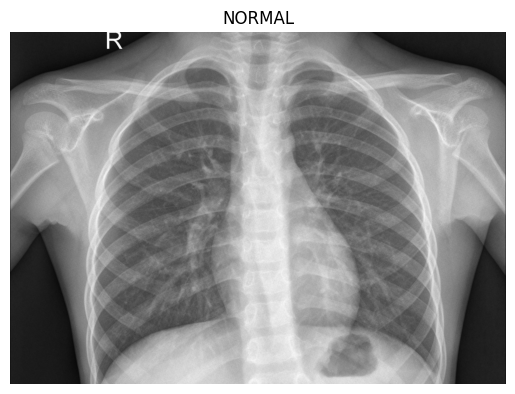

In [26]:
def show_a_sample_with_layers(path):
    from PIL import Image
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    img = Image.open(path)
    img_array = np.array(img) 

    width = img.size[0]
    height = img.size[1]
    
    if len(img_array.shape) == 2:
        layers = 1
    else:
        layers = img_array.shape[2]

    print(f"Original image format: {img.format}")
    print(f"Image mode: {img.mode}")
    print(f"(Height, Width, Layers): ({height}, {width}, {layers})")

    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.grid(False)
    plt.title('NORMAL')
    plt.show()
    
show_a_sample_with_layers(
    f"{base_path}/test/NORMAL/IM-0001-0001.jpeg"
)

In [27]:
import os

def check_class_balance(path):
    """Counts files in each subdirectory of a given path to check for class balance."""
    
    class_counts = {}
    print(f"Checking balance for: {path}\n")
    
    try:
        # Get class names (subdirectories)
        class_names = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        
        if not class_names:
            print("No class subdirectories found in this path.")
            return

        print("Class Counts:")
        # Loop through each class, count files, and store in the dictionary
        for class_name in class_names:
            class_path = os.path.join(path, class_name)
            # Count the number of files in the directory
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
            print(f"- {class_name}: {count} images")

        # --- Check for Imbalance ---
        counts = list(class_counts.values())
        if len(counts) > 1:
            min_count = min(counts)
            max_count = max(counts)
            
            # A common rule of thumb: imbalance exists if the largest class
            # is more than double the size of the smallest class.
            if max_count > min_count * 2:
                print("\nResult: 🔴 The dataset is *imbalanced*.")
            else:
                print("\nResult: 🟢 The dataset is *relatively balanced*.")
        else:
            print("\nResult: Only one class found, cannot check balance.")
            
    except FileNotFoundError:
        print(f"Error: Path not found: {path}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Run the check ---
train_path = f'{base_path}/train'

check_class_balance(train_path)

# It's also good practice to check your test set
print("\n" + "="*30 + "\n")
test_path = f'{base_path}/test'
check_class_balance(test_path)

Checking balance for: C:/Users/7400/Downloads/New folder/Grad-Project/chest_xray_dataset/train

Class Counts:
- NORMAL: 1341 images
- PNEUMONIA: 3875 images

Result: 🔴 The dataset is *imbalanced*.


Checking balance for: C:/Users/7400/Downloads/New folder/Grad-Project/chest_xray_dataset/test

Class Counts:
- NORMAL: 234 images
- PNEUMONIA: 390 images

Result: 🟢 The dataset is *relatively balanced*.


# **<span style="color:red">Data Preprocessing</span>**

In [28]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [29]:
IMG_SIZE = (224, 224)   # or (224, 224)
BATCH_SIZE = 32

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize
    rotation_range=20,        # rotate
    zoom_range=0.2,           # zoom
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
)


In [31]:
test_val_datagen = ImageDataGenerator(
    rescale=1./255
)


In [32]:
# Define paths
train_dir = f'{base_path}/train'
val_dir = f'{base_path}/val'
test_dir = f'{base_path}/test'


In [33]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.


In [34]:
val_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 16 images belonging to 2 classes.


In [35]:
test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 624 images belonging to 2 classes.


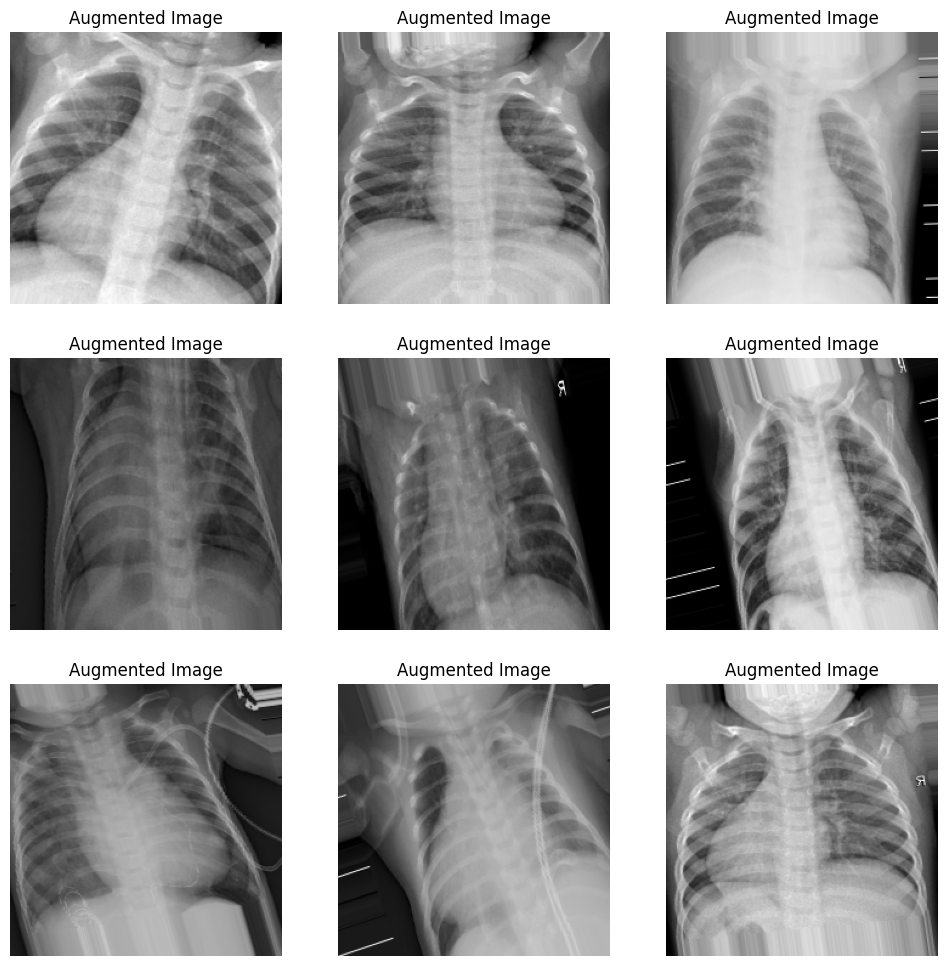

In [36]:


# Take 1 batch from the generator
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.title("Augmented Image")
    plt.axis("off")

plt.show()


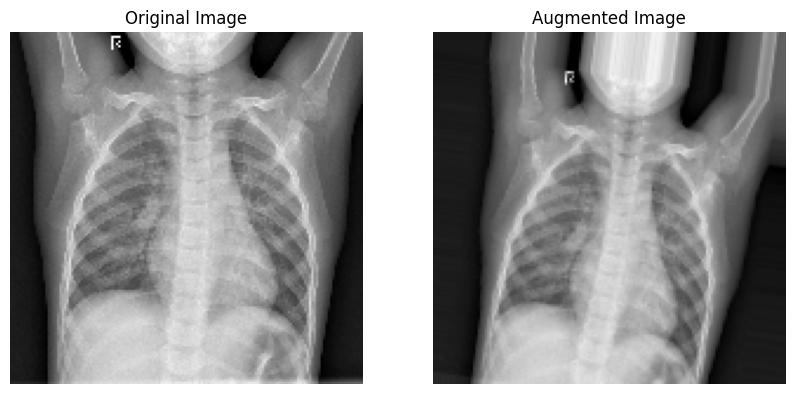

In [37]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import matplotlib.pyplot as plt

# get only image files
image_files = [f for f in os.listdir(train_dir + "/NORMAL") 
               if f.endswith(('.png', '.jpg', '.jpeg'))]

img_path = train_dir + "/NORMAL/" + image_files[0]

original = load_img(img_path, target_size=(150,150))
original_arr = img_to_array(original) / 255.0

augmented = train_datagen.random_transform(original_arr)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_arr)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented)
plt.title("Augmented Image")
plt.axis("off")

plt.show()





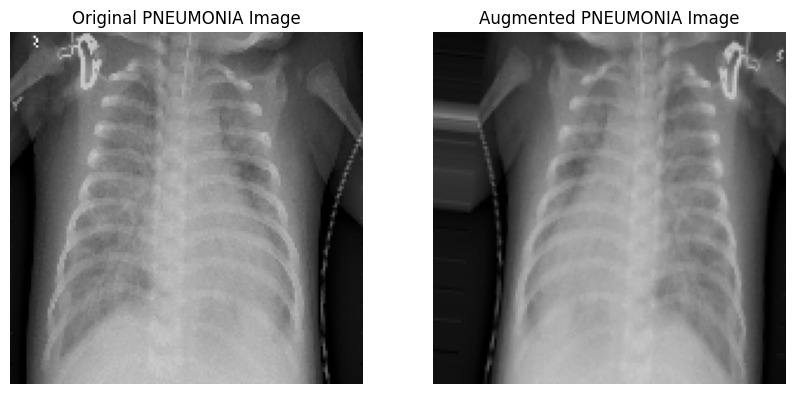

In [38]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import matplotlib.pyplot as plt

# get only image files
image_files = [f for f in os.listdir(train_dir + "/PNEUMONIA") 
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

img_path = train_dir + "/PNEUMONIA/" + image_files[0]

# Load original image (resize to 150x150)
original = load_img(img_path, target_size=(150,150))
original_arr = img_to_array(original) / 255.0

# Apply augmentation
augmented = train_datagen.random_transform(original_arr)

# Plot images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_arr.astype('float32'), cmap='gray')
plt.title("Original PNEUMONIA Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented.astype('float32'), cmap='gray')
plt.title("Augmented PNEUMONIA Image")
plt.axis("off")

plt.show()



## Building CNN Model 

In [46]:
model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (224, 224, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.3), 
    Dense(1, activation = 'sigmoid') # binary classification
])

In [47]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(learning_rate = 0.001),
    metrics=['accuracy']
)

In [48]:
checkpoint = ModelCheckpoint(
	'best_model.keras',
	monitor='val_accuracy',
	save_best_only=True
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

red_plateau =		ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)



history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop , checkpoint,red_plateau]
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.7453 - loss: 0.5771 - val_accuracy: 0.8125 - val_loss: 0.4440 - learning_rate: 0.0010
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.8530 - loss: 0.3334 - val_accuracy: 0.7500 - val_loss: 0.4831 - learning_rate: 0.0010
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8772 - loss: 0.2817 - val_accuracy: 0.8125 - val_loss: 0.5149 - learning_rate: 0.0010
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.8794 - loss: 0.2780 - val_accuracy: 0.8125 - val_loss: 0.5029 - learning_rate: 0.0010
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.9103 - loss: 0.2222 - val_accuracy: 0.6250 - val_loss: 0.7940 - learning_rate: 0.0010
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.9208 - loss: 0.2061 - val_accuracy: 0.9375 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.9223 - loss: 0.

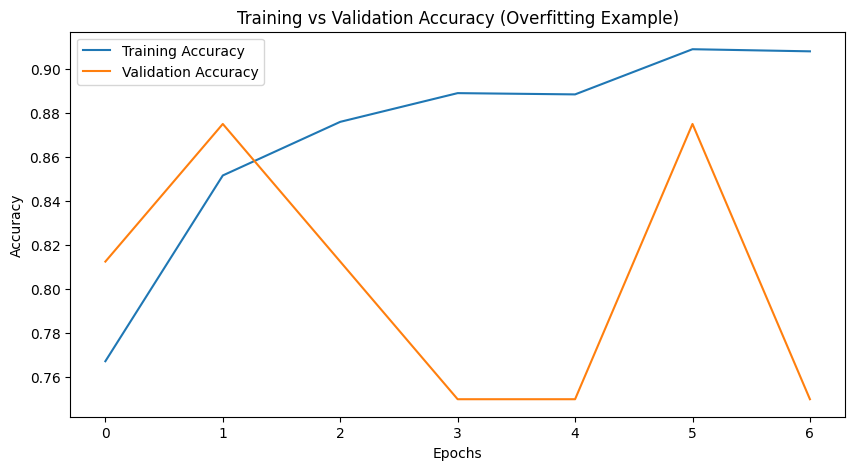

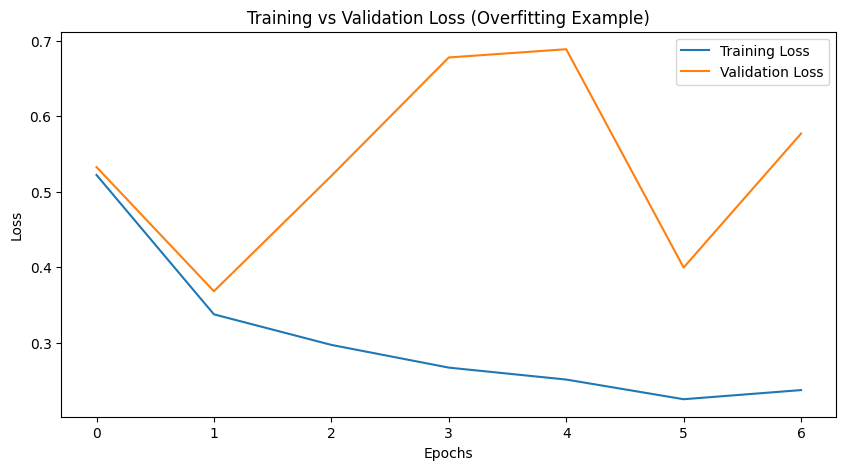

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

#  accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy (Overfitting Example)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#  loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (Overfitting Example)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Model Evaluation

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from PIL import Image

# Load the saved model (as in the image: model.h5)
model = load_model('best_model.keras')

#  Prepare test generator 
test_dir  = f'{base_path}/test'  
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),   
    batch_size=32,
    class_mode='binary',
    shuffle=False      
)


Found 624 images belonging to 2 classes.


In [ ]:

# ( accuracy , loss)
loss, acc = model.evaluate(test_generator, verbose=1)
print("\nTest loss:", loss)
print("Test accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 494ms/step - accuracy: 0.8793 - loss: 0.4169

Test loss: 0.2906825542449951
Test accuracy: 0.9070512652397156


In [ ]:

#  Generate predictions (probabilities)  
probs = model.predict(test_generator, verbose=1)
y_pred = (probs.ravel() >= 0.5).astype(int)   
y_true = test_generator.classes               
class_indices = test_generator.class_indices  
idx_to_class = {v:k for k,v in class_indices.items()}


20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 714ms/step


In [ ]:
#   ( Accuracy, Precision, Recall, F1-score )
print("\n--- Metrics on test set ---")
print("Accuracy (sklearn):", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1-score:", f1_score(y_true, y_pred, zero_division=0))





--- Metrics on test set ---
Accuracy (sklearn): 0.8477564102564102
Precision: 0.9351032448377581
Recall: 0.8128205128205128
F1-score: 0.869684499314129


In [ ]:
#  classification report (precision/recall/f1 per class)
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.92      0.83      0.87       234
   PNEUMONIA       0.90      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624




Confusion Matrix:
 [[194  40]
 [ 18 372]]


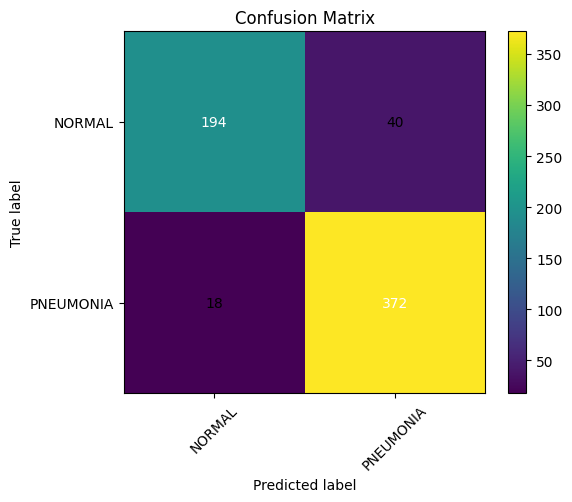

In [ ]:

#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()


In [ ]:

#  Identify misclassified sample
filenames = test_generator.filenames   
errors_idx = np.where(y_pred != y_true)[0]
print("\nMisclassified samples count:", len(errors_idx))




Misclassified samples count: 58


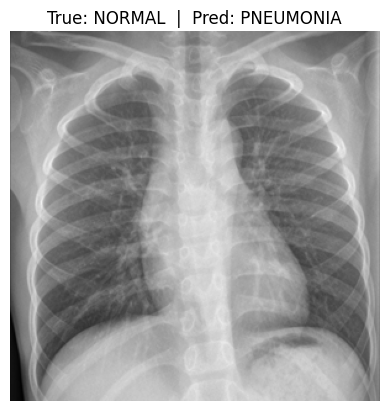

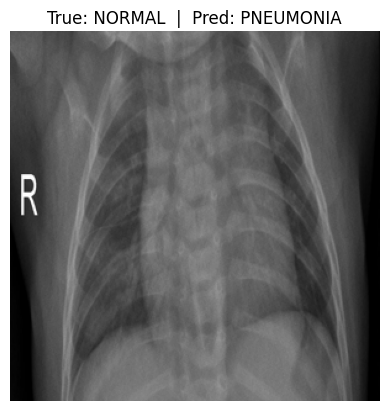

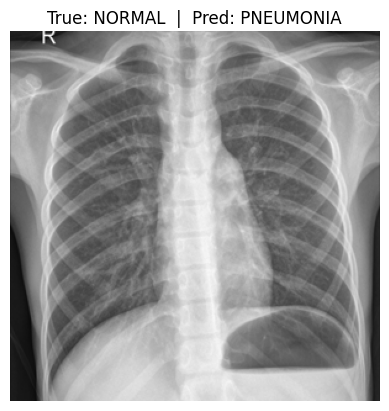

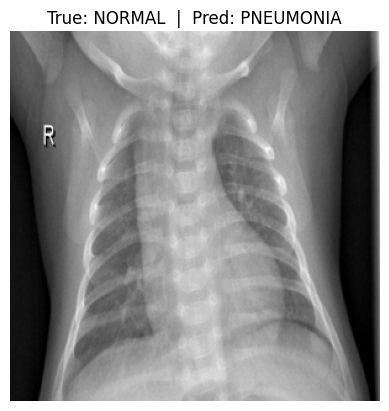

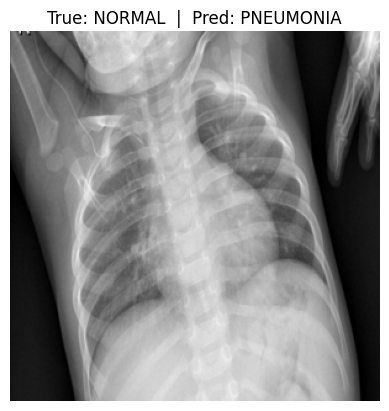

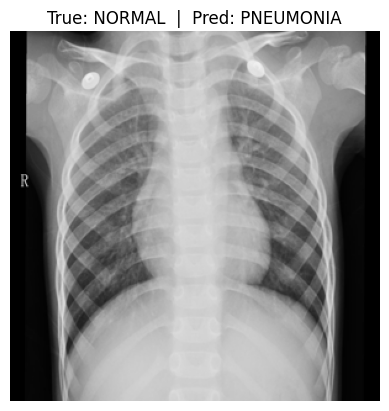

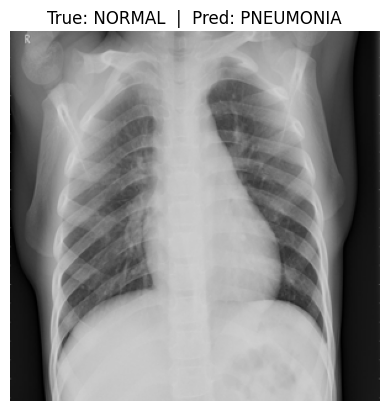

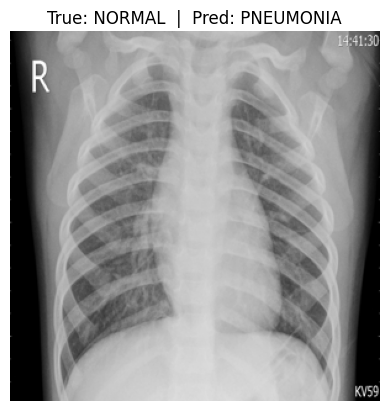

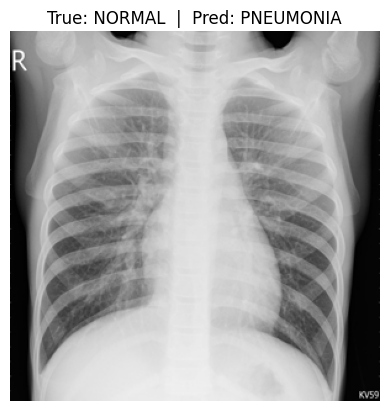

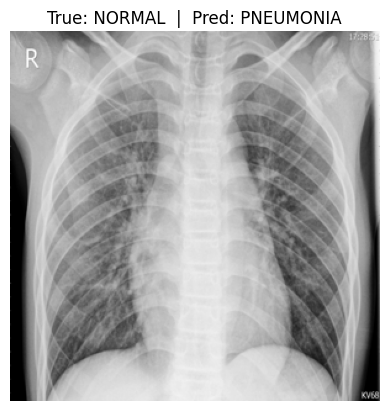

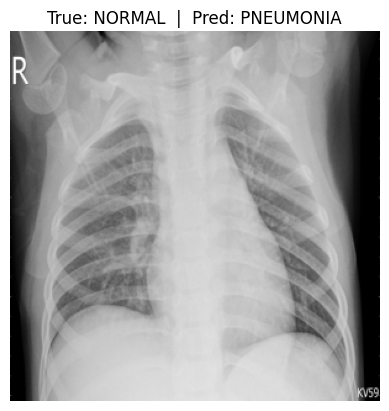

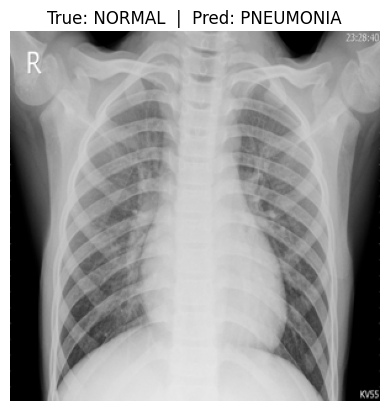

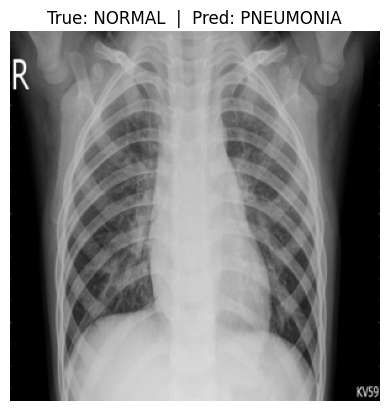

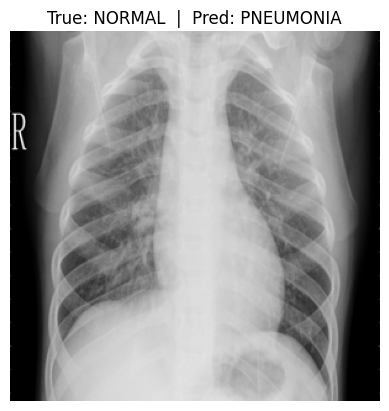

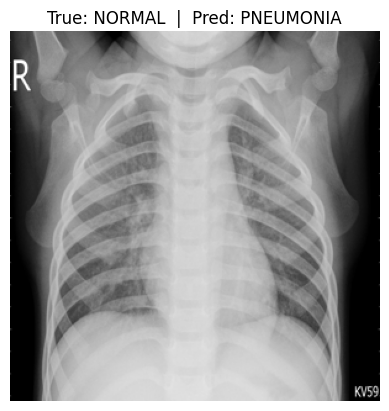

In [ ]:
for idx in errors_idx[:15]:
    rel_path = filenames[idx]                 
    img_path = os.path.join(test_dir, rel_path)
    img = Image.open(img_path).convert('RGB')
    display_img = img.resize((300,300))
    plt.figure()
    plt.imshow(display_img)
    plt.axis('off')
    true_label = idx_to_class[int(y_true[idx])]
    pred_label = idx_to_class[int(y_pred[idx])]
    plt.title(f"True: {true_label}  |  Pred: {pred_label}")
    plt.show()